# **CreditTransAct**

# Python-based Synthetic Data Generation Code

In [1]:
import subprocess, sys

for pkg in ["pyarrow", "tqdm", "numpy", "pandas"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])


import os
OUTPUT_DIR   = "/content/drive/MyDrive/CreditTransAct"
PARTS_DIR    = os.path.join(OUTPUT_DIR, "_parts")
os.makedirs(PARTS_DIR, exist_ok=True)

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import time, gc, warnings, json
from tqdm import tqdm
warnings.filterwarnings("ignore")

SEED         = 42
rng          = np.random.default_rng(SEED)

TOTAL_RECORDS = 15_000_000
CHUNK_SIZE    =    250_000

SEGMENTS = {

    "A_established": dict(share=0.40, fraud_rate=0.025, ctype="customer_based"),
    "B_regular":     dict(share=0.30, fraud_rate=0.040, ctype="customer_based"),
    "C_new":         dict(share=0.20, fraud_rate=0.070, ctype="customer_based"),
    "D_guest":       dict(share=0.10, fraud_rate=0.120, ctype="global"),
}


CUSTOMER_POOL = {
    "A_established": 120_000,
    "B_regular":     150_000,
    "C_new":         200_000,
    "D_guest":       None,
}

LABEL_NOISE_RATE = 0.018

# Customer Registry
MERCHANT_CATS = ["grocery","utility","retail","travel",
                 "luxury","electronics","crypto_giftcard","restaurant","healthcare"]

CITIES = ["home_city","same_country","neighboring_country","foreign_far"]

def build_customer_registry(segment, n_customers, rng):
    """
    Build a DataFrame of customer profiles — one row per customer.
    These profiles are FIXED for a customer across all their transactions,
    forming the 'baseline' that behavioral deviation is measured against.

    Returns dict keyed by customer_id.
    """
    seg_rng = np.random.default_rng(SEED + abs(hash(segment)) % 99999)

    age_range = {
        "A_established": (730, 3650),
        "B_regular":     (180, 730),
        "C_new":         (7,   180),
    }
    lo, hi = age_range[segment]

    # Baseline spend: what this customer normally spends per transaction
    baseline_spend = np.exp(seg_rng.normal(4.2, 1.0, n_customers)).clip(5, 2000)

    # Usual merchant category (most frequent for this customer)
    usual_merchant = seg_rng.choice(MERCHANT_CATS, size=n_customers,
                                     p=[0.22,0.12,0.20,0.12,0.04,0.10,0.03,0.11,0.06])

    # Account age in days
    account_age = seg_rng.integers(lo, hi, n_customers)

    # Historical chargeback count
    chargeback_count = seg_rng.choice([0,1,2,3,5],
                                       p=[0.88,0.08,0.03,0.01,0.00],
                                       size=n_customers)

    # Days since last credential change
    cred_change_days = seg_rng.choice([-1, 0, 3, 14, 60],
                                       p=[0.85, 0.03, 0.04, 0.05, 0.03],
                                       size=n_customers)

    # Home location type (where they usually transact)
    home_location = seg_rng.choice(
        ["home_city","same_country"],
        p=[0.70, 0.30],
        size=n_customers
    )

    # Number of cards on their device (stable baseline)
    cards_on_device = seg_rng.choice([1,2,3],
                                      p=[0.80,0.15,0.05],
                                      size=n_customers)

    ids = [f"CUST_{segment[:1]}_{str(i).zfill(7)}" for i in range(n_customers)]

    registry = {
        ids[i]: {
            "baseline_spend":    float(baseline_spend[i]),
            "usual_merchant":    usual_merchant[i],
            "account_age_days":  int(account_age[i]),
            "chargeback_count":  int(chargeback_count[i]),
            "cred_change_days":  int(cred_change_days[i]),
            "home_location":     home_location[i],
            "cards_on_device":   int(cards_on_device[i]),
        }
        for i in range(n_customers)
    }
    print(f"  {segment}: {n_customers:,} customer profiles built.")
    return registry


def build_all_registries():
    registries = {}
    for seg, cfg in SEGMENTS.items():
        pool_size = CUSTOMER_POOL[seg]
        if pool_size is None:
            registries[seg] = None
            continue
        registries[seg] = build_customer_registry(seg, pool_size, rng)
    return registries

print("Building customer registries...")
REGISTRIES = build_all_registries()
REGISTRY_SIZES = {s: len(r) if r else 0 for s, r in REGISTRIES.items()}
print("Customer pool sizes:", REGISTRY_SIZES)


# CELL 4 — Feature Generators (history-aware)
def wc(rng, options, weights, n):
    p = np.array(weights, dtype=float); p /= p.sum()
    return rng.choice(options, size=n, p=p)


def gen_transaction_amount(n, is_fraud, baseline_spend, rng):
    """
    Amount generated relative to customer's baseline spend.
    Fraud: card-testing (tiny) OR large deviation from baseline.
    """
    amounts = np.empty(n, dtype=np.float32)
    fm, lm = is_fraud, ~is_fraud

    legit_mean = np.log(baseline_spend[lm].clip(1, 5000))
    amounts[lm] = np.exp(rng.normal(legit_mean, 0.6)).clip(0.5, 9999)

    n_fraud = fm.sum()
    is_card_test = rng.random(n_fraud) < 0.30
    card_test_amt = rng.uniform(0.5, 12, n_fraud)
    large_amt = np.exp(
        np.log(baseline_spend[fm].clip(1,5000) * rng.uniform(3, 15, n_fraud))
    ).clip(50, 9999)
    fraud_amounts = np.where(is_card_test, card_test_amt, large_amt)
    amounts[fm] = fraud_amounts.astype(np.float32)

    amounts = np.round(amounts.clip(0.5, 9999), 2)

    # Deviation from customer baseline (in sigma units) — key behavioral feature
    sigma_dev = np.abs(amounts - baseline_spend) / (baseline_spend * 0.5 + 1)
    sigma_dev = np.round(sigma_dev.clip(0, 10), 2)

    bins   = [-np.inf, 50, 500, 2000, np.inf]
    labels = ["low","medium","high","very_high"]
    binned = pd.cut(amounts, bins=bins, labels=labels).astype(str)

    return {
        "transaction_amount":           amounts,
        "transaction_amount_bin":       np.array(binned),
        "avg_amount_deviation_sigma":   sigma_dev.astype(np.float32),
    }


def gen_merchant_features(n, is_fraud, usual_merchant, segment, rng):
    """
    Merchant category generated with awareness of customer's usual category.
    Fraud tends toward categories the customer has NEVER used.
    """
    high_risk = ["luxury","electronics","crypto_giftcard"]
    low_risk  = ["grocery","utility","restaurant","healthcare"]
    all_cats  = MERCHANT_CATS

    fraud_w  = [0.05,0.03,0.10,0.09,0.18,0.22,0.17,0.10,0.06]
    legit_w  = [0.22,0.12,0.20,0.12,0.04,0.10,0.03,0.11,0.06]

    cat      = np.empty(n, dtype=object)
    risk     = np.empty(n, dtype=object)
    vs_hist  = np.empty(n, dtype=object)

    fm, lm = is_fraud, ~is_fraud

    if lm.sum():
        # Legitimate: 70% usual category, 30% random
        use_usual = rng.random(lm.sum()) < 0.70
        rand_cats  = wc(rng, all_cats, legit_w, lm.sum())
        cat[lm]   = np.where(use_usual, usual_merchant[lm], rand_cats)

    if fm.sum():
        # Fraud: 60% high-risk or never-before
        use_hvrisk = rng.random(fm.sum()) < 0.60
        risky_cats = wc(rng, high_risk, [0.30,0.38,0.32], fm.sum())
        rand_cats2 = wc(rng, all_cats,  fraud_w, fm.sum())
        cat[fm]   = np.where(use_hvrisk, risky_cats, rand_cats2)

    # Merchant risk score
    def to_risk(c):
        if c in ["luxury","crypto_giftcard"]: return "very_high_risk"
        if c in ["electronics","travel"]:     return "high_risk"
        if c in ["retail","restaurant"]:      return "medium_risk"
        return "low_risk"
    risk = np.array([to_risk(c) for c in cat])

    # vs_history: compare to customer's usual_merchant
    for i in range(n):
        c, u = cat[i], usual_merchant[i]
        if c == u:
            vs_hist[i] = "frequent_category"
        elif (c in low_risk and u in low_risk) or (c in high_risk and u in high_risk):
            vs_hist[i] = "occasional_category"
        elif is_fraud[i] and c in high_risk and u not in high_risk:
            vs_hist[i] = "never_before_category"
        else:
            vs_hist[i] = "rare_category"

    if segment == "D_guest":
        vs_hist[:] = "no_history"

    return {
        "merchant_category":            cat,
        "merchant_risk_score":          risk,
        "merchant_category_vs_history": vs_hist,
    }


def gen_geo_features(n, is_fraud, home_location, rng):
    """
    Geo velocity and distance computed relative to customer's home location.
    Impossible velocity co-occurs with foreign merchant location.
    """
    vel  = np.empty(n, dtype=np.float32)
    dist = np.empty(n, dtype=np.float32)
    loc  = np.empty(n, dtype=object)
    cc   = np.empty(n, dtype=object)

    fm, lm = is_fraud, ~is_fraud

    # Legitimate
    if lm.sum():
        v_l = np.where(rng.random(lm.sum()) < 0.65,
                       rng.uniform(0, 5, lm.sum()),
                       rng.exponential(35, lm.sum())).clip(0, 499)
        vel[lm]  = v_l
        d_l = np.where(rng.random(lm.sum()) < 0.60,
                       rng.uniform(0, 3, lm.sum()),
                       rng.exponential(20, lm.sum())).clip(0, 490)
        dist[lm] = d_l
        loc[lm]  = wc(rng, CITIES, [0.60,0.25,0.10,0.05], lm.sum())
        cc[lm]   = wc(rng, ["same_country","frequent_travel_country","new_country","high_risk_country"],
                       [0.72,0.16,0.10,0.02], lm.sum())

    # Fraud — correlated: impossible velocity ↔ foreign location
    if fm.sum():
        impossible = rng.random(fm.sum()) < 0.38
        vel[fm]   = np.where(impossible,
                             rng.uniform(500, 2500, fm.sum()),
                             rng.exponential(100, fm.sum()).clip(0, 499))
        dist[fm]  = np.where(impossible,
                             rng.uniform(600, 8000, fm.sum()),
                             rng.exponential(90, fm.sum()).clip(0, 490))
        loc[fm]   = np.where(impossible,
                             wc(rng, ["neighboring_country","foreign_far"], [0.3,0.7], fm.sum()),
                             wc(rng, CITIES, [0.20,0.25,0.30,0.25], fm.sum()))
        cc[fm]    = np.where(impossible,
                             wc(rng, ["new_country","high_risk_country"], [0.4,0.6], fm.sum()),
                             wc(rng, ["same_country","frequent_travel_country","new_country","high_risk_country"],
                                [0.18,0.18,0.32,0.32], fm.sum()))

    vel  = np.round(vel,  1).astype(np.float32)
    dist = np.round(dist, 1).astype(np.float32)

    vbins = pd.cut(vel,  [-np.inf,50,500,np.inf], labels=["normal","fast","impossible"]).astype(str)
    dbins = pd.cut(dist, [-np.inf,50,500,np.inf], labels=["same_location","short","long"]).astype(str)

    return {
        "geo_velocity_kmh":   vel,
        "geo_velocity_bin":   np.array(vbins),
        "geo_distance_km":    dist,
        "geo_distance_bin":   np.array(dbins),
        "merchant_location":  loc,
        "country_consistency": cc,
    }


def gen_device_network(n, is_fraud, cards_baseline, segment, rng):
    """
    Device and network signals.
    Cards on device computed relative to customer's baseline card count.
    Bot-speed session co-occurs with emulator/spoofed device.
    """
    ip_type  = np.empty(n, dtype=object)
    dev      = np.empty(n, dtype=object)
    session  = np.empty(n, dtype=np.float32)
    carrier  = np.empty(n, dtype=object)
    cards    = np.empty(n, dtype=np.int16)

    fm, lm = is_fraud, ~is_fraud

    ip_opts = ["residential","corporate","vpn","proxy","tor","datacenter"]
    dev_opts = ["known_device","new_device","unknown_device","emulator","spoofed"]
    car_opts = ["wifi","mobile_data","datacenter_hosting","corporate_vpn"]

    if lm.sum():
        ip_type[lm] = wc(rng, ip_opts, [0.65,0.18,0.08,0.04,0.01,0.04], lm.sum())
        dev[lm]     = wc(rng, dev_opts, [0.74,0.17,0.06,0.02,0.01], lm.sum())
        session[lm] = np.exp(rng.normal(4.8, 0.8, lm.sum())).clip(10, 1800)
        carrier[lm] = wc(rng, car_opts, [0.45,0.38,0.06,0.11], lm.sum())
        cards[lm]   = (cards_baseline[lm] + rng.integers(0, 2, lm.sum())).clip(1, 5).astype(np.int16)

    if fm.sum():
        # Correlated: bot_session ↔ emulator/spoofed ↔ tor/proxy
        bot_mask = rng.random(fm.sum()) < 0.52
        ip_type[fm] = np.where(bot_mask,
                               wc(rng, ["tor","proxy","datacenter"], [0.35,0.35,0.30], fm.sum()),
                               wc(rng, ip_opts, [0.10,0.05,0.22,0.25,0.20,0.18], fm.sum()))
        dev[fm]     = np.where(bot_mask,
                               wc(rng, ["emulator","spoofed"], [0.55,0.45], fm.sum()),
                               wc(rng, dev_opts, [0.08,0.20,0.22,0.28,0.22], fm.sum()))
        session[fm] = np.where(bot_mask,
                               rng.uniform(0.3, 5, fm.sum()),
                               np.exp(rng.normal(3.8, 1.0, fm.sum())).clip(5, 600))
        carrier[fm] = wc(rng, car_opts, [0.22,0.18,0.42,0.18], fm.sum())
        cards[fm]   = (cards_baseline[fm] + rng.integers(0, 15, fm.sum())).clip(1, 25).astype(np.int16)

    session = np.round(session, 1)
    sbins = pd.cut(session, [-np.inf,5,30,180,np.inf],
                   labels=["bot_speed","very_fast","normal","slow"]).astype(str)

    return {
        "ip_address_type":           ip_type,
        "device_fingerprint_match":  dev,
        "session_duration_sec":      session,
        "session_duration_bin":      np.array(sbins),
        "network_carrier_type":      carrier,
        "cards_on_device_30d":       cards,
    }


def gen_authentication(n, is_fraud, segment, rng):
    """
    CVV, 3DS, tokenization, and failed attempts.
    Correlated: CVV mismatch ↔ raw_pan ↔ challenge_fail (CNP fraud cluster).
    """
    cvv    = np.empty(n, dtype=object)
    tds    = np.empty(n, dtype=object)
    token  = np.empty(n, dtype=object)
    fails  = np.empty(n, dtype=np.int8)

    fm, lm = is_fraud, ~is_fraud

    cvv_opts   = ["cvv2_match","cvv2_mismatch","not_provided","icvv_match"]
    tds_opts   = ["frictionless_pass","challenge_pass","challenge_fail","not_enrolled","bypassed"]
    token_opts = ["network_token_wallet","issuer_token","raw_pan_online",
                  "raw_pan_manual_entry","emv_chip_token"]

    if lm.sum():
        cvv[lm]   = wc(rng, cvv_opts,   [0.76,0.04,0.05,0.15], lm.sum())
        tds[lm]   = wc(rng, tds_opts,   [0.50,0.28,0.03,0.12,0.07], lm.sum())
        token[lm] = wc(rng, token_opts, [0.28,0.18,0.22,0.08,0.24], lm.sum())
        fails[lm] = rng.choice([0,1,2,3,5], p=[0.82,0.10,0.05,0.02,0.01], size=lm.sum())

    if fm.sum():
        # CNP fraud cluster: CVV mismatch + raw PAN + challenge fail — co-occur
        cnp_fraud = rng.random(fm.sum()) < 0.60
        cvv[fm]   = np.where(cnp_fraud,
                             wc(rng, ["cvv2_mismatch","not_provided"], [0.55,0.45], fm.sum()),
                             wc(rng, cvv_opts, [0.20,0.38,0.28,0.14], fm.sum()))
        tds[fm]   = np.where(cnp_fraud,
                             wc(rng, ["challenge_fail","bypassed","not_enrolled"], [0.40,0.35,0.25], fm.sum()),
                             wc(rng, tds_opts, [0.15,0.10,0.30,0.25,0.20], fm.sum()))
        token[fm] = np.where(cnp_fraud,
                             wc(rng, ["raw_pan_online","raw_pan_manual_entry"], [0.55,0.45], fm.sum()),
                             wc(rng, token_opts, [0.05,0.08,0.40,0.35,0.12], fm.sum()))
        fails[fm] = rng.choice([0,1,2,3,4,6,10],
                                p=[0.22,0.18,0.18,0.18,0.12,0.08,0.04],
                                size=fm.sum())

    return {
        "cvv_match_status":              cvv,
        "three_ds_auth_result":          tds,
        "tokenization_used":             token,
        "failed_attempts_before_success": fails,
    }


def gen_behavioral_temporal(n, is_fraud, cred_change_days, segment, rng):
    """
    Velocity, time of day, and credential change recency.
    ATO cluster: credential_change_within_24h ↔ burst_velocity ↔ late_night.
    """
    vel   = np.empty(n, dtype=object)
    time_ = np.empty(n, dtype=object)
    cred  = np.empty(n, dtype=object)
    cnp_  = np.empty(n, dtype=object)
    ship  = np.empty(n, dtype=object)

    fm, lm = is_fraud, ~is_fraud

    vel_opts  = ["within_normal","2x_baseline","5x_baseline","burst_pattern"]
    time_opts = ["morning_6_12","afternoon_12_18","evening_18_24","late_night_0_5"]
    cred_opts = ["no_recent_change","changed_7_30d_ago","changed_1_7d_ago","changed_within_24h"]
    cnp_opts  = ["card_present_chip","card_present_swipe","contactless",
                 "cnp_online","cnp_moto","manual_entry"]
    ship_opts = ["standard","expedited","overnight","same_day","in_store_pickup"]

    if lm.sum():
        vel[lm]   = wc(rng, vel_opts,  [0.78,0.14,0.05,0.03], lm.sum())
        time_[lm] = wc(rng, time_opts, [0.28,0.35,0.28,0.09], lm.sum())
        cnp_[lm]  = wc(rng, cnp_opts,  [0.30,0.15,0.28,0.18,0.05,0.04], lm.sum())
        ship[lm]  = wc(rng, ship_opts, [0.48,0.25,0.10,0.08,0.09], lm.sum())
        # Use actual customer credential change days
        cred[lm]  = np.where(cred_change_days[lm] == -1, "no_recent_change",
                    np.where(cred_change_days[lm] == 0,  "changed_within_24h",
                    np.where(cred_change_days[lm] <= 7,  "changed_1_7d_ago",
                                                          "changed_7_30d_ago")))

    if fm.sum():
        # ATO cluster: cred_change + burst + late_night — co-occur
        ato_mask = rng.random(fm.sum()) < 0.45
        vel[fm]   = np.where(ato_mask,
                             wc(rng, ["burst_pattern","5x_baseline"], [0.60,0.40], fm.sum()),
                             wc(rng, vel_opts, [0.12,0.18,0.35,0.35], fm.sum()))
        time_[fm] = np.where(ato_mask,
                             wc(rng, ["late_night_0_5","evening_18_24"], [0.70,0.30], fm.sum()),
                             wc(rng, time_opts, [0.12,0.18,0.28,0.42], fm.sum()))
        cred[fm]  = np.where(ato_mask,
                             wc(rng, ["changed_within_24h","changed_1_7d_ago"], [0.65,0.35], fm.sum()),
                             wc(rng, cred_opts, [0.28,0.15,0.25,0.32], fm.sum()))
        cnp_[fm]  = wc(rng, cnp_opts, [0.02,0.01,0.04,0.60,0.18,0.15], fm.sum())
        ship[fm]  = wc(rng, ship_opts, [0.05,0.12,0.38,0.40,0.05], fm.sum())

    if segment == "D_guest":
        cred[:] = "not_applicable"

    return {
        "transaction_velocity_1h":             vel,
        "time_of_transaction":                 time_,
        "account_credential_change_recency":   cred,
        "card_present_cnp":                    cnp_,
        "order_shipping_speed":                ship,
    }


# Fraud Score + Label Noise
def compute_fraud_score(d):
    """Compound fraud score from feature interactions (0–1)."""
    s = np.zeros(len(d["transaction_amount"]), dtype=np.float32)

    # Geo cluster
    s += np.where(np.array(d["geo_velocity_bin"]) == "impossible", 0.22, 0)
    s += np.where(np.array(d["geo_distance_bin"]) == "long",        0.08, 0)
    s += np.where(np.array(d["country_consistency"]) == "high_risk_country", 0.10, 0)

    # Network/Device cluster
    s += np.where(np.isin(d["ip_address_type"], ["tor","proxy"]),    0.20, 0)
    s += np.where(np.isin(d["device_fingerprint_match"], ["emulator","spoofed"]), 0.18, 0)
    s += np.where(np.array(d["session_duration_bin"]) == "bot_speed", 0.16, 0)
    s += np.where(np.array(d["cards_on_device_30d"]) > 4,             0.10, 0)

    # Auth cluster
    s += np.where(np.isin(d["cvv_match_status"], ["cvv2_mismatch","not_provided"]), 0.20, 0)
    s += np.where(np.isin(d["three_ds_auth_result"], ["challenge_fail","bypassed"]), 0.16, 0)
    s += np.where(np.array(d["failed_attempts_before_success"]) >= 3, 0.16, 0)
    s += np.where(np.isin(d["tokenization_used"], ["raw_pan_online","raw_pan_manual_entry"]), 0.07, 0)

    # Behavioral cluster (ATO)
    s += np.where(np.isin(d["transaction_velocity_1h"], ["5x_baseline","burst_pattern"]), 0.15, 0)
    s += np.where(np.array(d["merchant_category_vs_history"]) == "never_before_category", 0.10, 0)
    s += np.where(np.array(d["account_credential_change_recency"]) == "changed_within_24h", 0.16, 0)
    s += np.where(np.array(d["avg_amount_deviation_sigma"]) > 3.0, 0.12, 0)

    # Supporting
    s += np.where(np.isin(d["merchant_risk_score"], ["high_risk","very_high_risk"]), 0.06, 0)
    s += np.where(np.isin(d["order_shipping_speed"], ["overnight","same_day"]), 0.05, 0)
    s += np.where(np.array(d["chargeback_history_count"]) >= 3, 0.08, 0)

    return np.clip(s, 0, 1)


def inject_noise(is_fraud, score, rng, rate=LABEL_NOISE_RATE):
    is_fraud = is_fraud.copy()
    borderline = (score >= 0.35) & (score <= 0.65)
    cands = np.where(borderline)[0]
    n_flip = int(len(cands) * rate)
    if n_flip > 0:
        flip = rng.choice(cands, size=n_flip, replace=False)
        is_fraud[flip] = ~is_fraud[flip]
    return is_fraud


# Chunk Builder
def build_chunk(segment, n, fraud_rate, registry, chunk_id, seg_rng):
    """
    Build one chunk of n records.
    For customer-based segments, customers are sampled from the registry
    so their profile (baseline_spend, usual_merchant, etc.) is used.
    """
    cfg = SEGMENTS[segment]

    # Assign fraud labels by target rate
    n_fraud = int(n * fraud_rate)
    n_legit = n - n_fraud
    is_fraud = np.array([True]*n_fraud + [False]*n_legit)
    seg_rng.shuffle(is_fraud)

    # Sample customer profiles
    if registry is not None:
        cust_ids_all  = list(registry.keys())
        chosen_keys   = seg_rng.choice(cust_ids_all, size=n, replace=True)
        profiles      = [registry[k] for k in chosen_keys]

        baseline_spend   = np.array([p["baseline_spend"]   for p in profiles], dtype=np.float32)
        usual_merchant   = np.array([p["usual_merchant"]   for p in profiles])
        account_age_days = np.array([p["account_age_days"] for p in profiles], dtype=np.int16)
        chargeback_count = np.array([p["chargeback_count"] for p in profiles], dtype=np.int8)
        cred_change_days = np.array([p["cred_change_days"] for p in profiles], dtype=np.int16)
        home_location    = np.array([p["home_location"]    for p in profiles])
        cards_baseline   = np.array([p["cards_on_device"]  for p in profiles], dtype=np.int16)
        cust_id_arr      = np.array(chosen_keys)
        ctype            = "customer_based"
    else:
        # Guest: no profile — use global defaults
        n_guests = n
        baseline_spend   = np.exp(seg_rng.normal(4.0, 1.2, n)).astype(np.float32).clip(1, 5000)
        usual_merchant   = seg_rng.choice(MERCHANT_CATS, size=n)
        account_age_days = np.zeros(n, dtype=np.int16)
        chargeback_count = np.zeros(n, dtype=np.int8)
        cred_change_days = np.full(n, -1, dtype=np.int16)
        home_location    = seg_rng.choice(["home_city","same_country"], size=n)
        cards_baseline   = np.ones(n, dtype=np.int16)
        cust_id_arr      = np.array([f"GUEST_{chunk_id}_{i}" for i in range(n)])
        ctype            = "global"

    # Generate features
    d = {}
    d.update(gen_transaction_amount(n, is_fraud, baseline_spend, seg_rng))
    d.update(gen_merchant_features(n, is_fraud, usual_merchant, segment, seg_rng))
    d.update(gen_geo_features(n, is_fraud, home_location, seg_rng))
    d.update(gen_device_network(n, is_fraud, cards_baseline, segment, seg_rng))
    d.update(gen_authentication(n, is_fraud, segment, seg_rng))
    d.update(gen_behavioral_temporal(n, is_fraud, cred_change_days, segment, seg_rng))

    # Account-level features from profile
    d["account_age_days"]       = account_age_days
    d["chargeback_history_count"] = chargeback_count

    # Fraud score + noise
    score      = compute_fraud_score(d)
    is_fraud_f = inject_noise(is_fraud, score, seg_rng)

    # IDs & labels
    d["customer_id"]    = cust_id_arr
    d["transaction_id"] = np.array([f"TXN_{chunk_id}_{str(i).zfill(7)}" for i in range(n)])
    d["segment"]        = np.full(n, segment, dtype=object)
    d["customer_type"]  = np.full(n, ctype,   dtype=object)
    d["is_fraud"]       = is_fraud_f.astype(np.int8)

    return pd.DataFrame(d)


# Main Loop
def main():
    # Segment sizes
    seg_sizes = {s: int(TOTAL_RECORDS * cfg["share"]) for s, cfg in SEGMENTS.items()}
    diff = TOTAL_RECORDS - sum(seg_sizes.values())
    seg_sizes["A_established"] += diff

    print("\nRecord allocation:")
    for s, sz in seg_sizes.items():
        print(f"  {s:<20} {sz:>9,}  "
              f"fraud={SEGMENTS[s]['fraud_rate']*100:.1f}%  "
              f"type={SEGMENTS[s]['ctype']}")

    # Part file tracking
    part_files   = []
    chunk_id     = 0
    total_fraud  = 0
    total_rows   = 0
    start        = time.time()

    for segment, total_sz in seg_sizes.items():
        fraud_rate = SEGMENTS[segment]["fraud_rate"]
        registry   = REGISTRIES[segment]
        n_chunks   = (total_sz + CHUNK_SIZE - 1) // CHUNK_SIZE
        seg_rng    = np.random.default_rng(SEED + abs(hash(segment)) % 99999)

        print(f"\n [{segment}] {total_sz:,} records | {n_chunks} chunks")

        remaining = total_sz
        for c in tqdm(range(n_chunks), desc=f"  {segment}", unit="chunk"):
            n = min(CHUNK_SIZE, remaining)
            if n <= 0: break

            chunk_df = build_chunk(segment, n, fraud_rate, registry, chunk_id, seg_rng)

            # Write to Parquet part file immediately
            part_path = os.path.join(PARTS_DIR, f"part_{chunk_id:05d}.parquet")
            chunk_df.to_parquet(part_path, index=False, compression="snappy")
            part_files.append(part_path)

            total_fraud += int(chunk_df["is_fraud"].sum())
            total_rows  += len(chunk_df)

            # FREE MEMORY immediately
            del chunk_df
            gc.collect()

            remaining -= n
            chunk_id  += 1

    elapsed    = time.time() - start
    fraud_pct  = total_fraud / total_rows * 100
    legit_pct  = 100 - fraud_pct

    print(f"\n\n Generation done in {elapsed:.1f}s")
    print(f"   Rows    : {total_rows:,}")
    print(f"   Fraud   : {total_fraud:,} ({fraud_pct:.2f}%)")
    print(f"   Non-fraud: {total_rows - total_fraud:,} ({legit_pct:.2f}%)")
    print(f"   Parts   : {len(part_files)} files in {PARTS_DIR}")

    # Merge parts into one Parquet dataset
    print("\n Merging parts into final Parquet (streaming, no RAM spike)...")
    final_parquet = os.path.join(OUTPUT_DIR, "credit_card_fraud.parquet")

    dataset = ds.dataset(PARTS_DIR, format="parquet")
    pq.write_to_dataset(
        dataset.to_table(),
        root_path=OUTPUT_DIR,
        basename_template="credit_card_fraud_{i}.parquet",
        existing_data_behavior="overwrite_or_ignore",
    )
    # Rename to single file
    import glob
    out_parts = sorted(glob.glob(os.path.join(OUTPUT_DIR, "credit_card_fraud_*.parquet")))
    if len(out_parts) == 1:
        os.rename(out_parts[0], final_parquet)
    else:
        final_parquet = out_parts[0]
        print(f"   Note: Dataset split into {len(out_parts)} shard files.")

    parquet_mb = sum(os.path.getsize(f) for f in
                     glob.glob(os.path.join(OUTPUT_DIR, "credit_card_fraud*.parquet"))) / 1e6
    print(f"   Parquet size: {parquet_mb:.1f} MB")

    meta_path = os.path.join(OUTPUT_DIR, "credit_card_fraud_metadata.txt")
    with open(meta_path, "w") as f:
        f.write(f"""CREDIT CARD FRAUD DETECTION — SYNTHETIC DATASET
===================================================
Generated     : {time.strftime('%Y-%m-%d %H:%M:%S')}
Total records : {total_rows:,}
Fraud records : {total_fraud:,} ({fraud_pct:.2f}%)
Non-fraud     : {total_rows-total_fraud:,} ({legit_pct:.2f}%)
Dataset type  : Hybrid (customer-based + global/guest)
Label noise   : {LABEL_NOISE_RATE*100:.1f}% on borderline cases
Generation    : {elapsed:.1f}s

SEGMENT BREAKDOWN:
{"".join([
    f"  {s:<22} {sz:>9,}  fraud={SEGMENTS[s]['fraud_rate']*100:.1f}%  pool={CUSTOMER_POOL[s] or 'none (guest)'}{chr(10)}"
    for s, sz in seg_sizes.items()
])}
CUSTOMER POOLS (repeating customers with history):
  A_established : {CUSTOMER_POOL['A_established']:,} unique customers  (~50 txns/customer avg)
  B_regular     : {CUSTOMER_POOL['B_regular']:,} unique customers  (~30 txns/customer avg)
  C_new         : {CUSTOMER_POOL['C_new']:,} unique customers  (~15 txns/customer avg)
  D_guest       : no pool - 1 txn per guest (global transactions)

CUSTOMER PROFILE ATTRIBUTES (per-customer baseline used for behavioral features):
  baseline_spend, usual_merchant, account_age_days, chargeback_count,
  cred_change_days, home_location, cards_on_device

FRAUD SIGNAL CLUSTERS:
  CNP cluster    : cvv2_mismatch + raw_pan + challenge_fail + (tor/proxy IP)
  Bot cluster    : bot_speed_session + emulator/spoofed + datacenter_IP + burst_velocity
  ATO cluster    : credential_change_within_24h + burst_velocity + late_night + never_before_merchant
  Geo cluster    : impossible_velocity + foreign_far + high_risk_country (co-occur)

OUTPUT FILES:
  {final_parquet}
  {meta_path}
""")
    print(f"   Metadata: {meta_path}")

    # Cleanup part files
    print("\n Cleaning up part files...")
    for pf in part_files:
        try: os.remove(pf)
        except: pass
    try: os.rmdir(PARTS_DIR)
    except: pass

    print("\n\n Complete! Files in:", OUTPUT_DIR)
    return final_parquet

final_path = main()

Building customer registries...
  A_established: 120,000 customer profiles built.
  B_regular: 150,000 customer profiles built.
  C_new: 200,000 customer profiles built.
Customer pool sizes: {'A_established': 120000, 'B_regular': 150000, 'C_new': 200000, 'D_guest': 0}

Record allocation:
  A_established        6,000,000  fraud=2.5%  type=customer_based
  B_regular            4,500,000  fraud=4.0%  type=customer_based
  C_new                3,000,000  fraud=7.0%  type=customer_based
  D_guest              1,500,000  fraud=12.0%  type=global

 [A_established] 6,000,000 records | 24 chunks


  A_established: 100%|██████████| 24/24 [02:32<00:00,  6.37s/chunk]



 [B_regular] 4,500,000 records | 18 chunks


  B_regular: 100%|██████████| 18/18 [01:23<00:00,  4.64s/chunk]



 [C_new] 3,000,000 records | 12 chunks


  C_new: 100%|██████████| 12/12 [00:56<00:00,  4.69s/chunk]



 [D_guest] 1,500,000 records | 6 chunks


  D_guest: 100%|██████████| 6/6 [00:19<00:00,  3.25s/chunk]




 Generation done in 312.3s
   Rows    : 15,000,000
   Fraud   : 735,265 (4.90%)
   Non-fraud: 14,264,735 (95.10%)
   Parts   : 60 files in /content/drive/MyDrive/CreditTransAct/_parts

 Merging parts into final Parquet (streaming, no RAM spike)...
   Parquet size: 510.9 MB
   Metadata: /content/drive/MyDrive/CreditTransAct/credit_card_fraud_metadata.txt

 Cleaning up part files...


 Complete! Files in: /content/drive/MyDrive/CreditTransAct


# **Exploratory Data Analysis (EDA)**

In [1]:
import os
import gc
import warnings
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.dataset as ds

warnings.filterwarnings("ignore")

PARQUET_PATH = "/content/drive/MyDrive/CreditTransAct/credit_card_fraud.parquet"
SAMPLE_ROWS  = 500_000
CHUNK_SIZE   =  250_000


print("1. FILE & SCHEMA INFO")

pf     = pq.ParquetFile(PARQUET_PATH)
schema = pf.schema_arrow

file_mb = os.path.getsize(PARQUET_PATH) / 1e6
total_rows = pf.metadata.num_rows

print(f"  File size     : {file_mb:,.1f} MB")
print(f"  Total rows    : {total_rows:,}")
print(f"  Total columns : {len(schema)}")
print(f"  Row groups    : {pf.metadata.num_row_groups}")
print()


print("2. COLUMN NAMES & DATA TYPES")
dtype_map = {}
for i, field in enumerate(schema):
    dtype_map[field.name] = str(field.type)
    print(f"  [{i:02d}] {field.name:<45} {field.type}")
print()


NUMERIC_COLS = [n for n, t in dtype_map.items()
                if any(x in t for x in ("int","float","double"))]
CATEG_COLS   = [n for n, t in dtype_map.items()
                if "string" in t or "dictionary" in t]

print(f"  Numeric columns  : {len(NUMERIC_COLS)}")
print(f"  Categorical cols : {len(CATEG_COLS)}")
print()


print("3. FIRST 5 ROWS")
first5 = pf.read_row_group(0).to_pandas().head(5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(first5.to_string(index=False))
del first5; gc.collect()
print()


print("4. LAST 5 ROWS")
last_rg = pf.metadata.num_row_groups - 1
last5   = pf.read_row_group(last_rg).to_pandas().tail(5)
print(last5.to_string(index=False))
del last5; gc.collect()
print()


print("5. UNIQUE VALUE COUNT PER COLUMN  (chunked full scan)")
unique_counts = {col: set() for col in CATEG_COLS}
numeric_nuniq = {col: set() for col in NUMERIC_COLS}

dataset = ds.dataset(PARQUET_PATH, format="parquet")

rows_read = 0
for batch in dataset.to_batches(batch_size=CHUNK_SIZE):
    chunk = batch.to_pydict()
    for col in CATEG_COLS:
        unique_counts[col].update(chunk[col])
    for col in NUMERIC_COLS:
        numeric_nuniq[col].update(chunk[col])
    rows_read += len(chunk[list(chunk.keys())[0]])
    print(f"  ... scanned {rows_read:,} / {total_rows:,} rows", end="\r")
    del chunk; gc.collect()

print()
print("\n  Categorical / Nominal / Ordinal columns:")
print(f"  {'Column':<45} {'Unique Values':>14}")
for col, vals in sorted(unique_counts.items()):
    print(f"  {col:<45} {len(vals):>14,}")

print("\n  Numeric columns:")
print(f"  {'Column':<45} {'Approx Unique':>14}")
for col, vals in sorted(numeric_nuniq.items()):
    print(f"  {col:<45} {len(vals):>14,}")

del unique_counts, numeric_nuniq; gc.collect()
print()


1. FILE & SCHEMA INFO
  File size     : 510.9 MB
  Total rows    : 15,000,000
  Total columns : 34
  Row groups    : 480

2. COLUMN NAMES & DATA TYPES
  [00] transaction_amount                            float
  [01] transaction_amount_bin                        string
  [02] avg_amount_deviation_sigma                    float
  [03] merchant_category                             string
  [04] merchant_risk_score                           string
  [05] merchant_category_vs_history                  string
  [06] geo_velocity_kmh                              float
  [07] geo_velocity_bin                              string
  [08] geo_distance_km                               float
  [09] geo_distance_bin                              string
  [10] merchant_location                             string
  [11] country_consistency                           string
  [12] ip_address_type                               string
  [13] device_fingerprint_match                      string
  [14] sessio

File: 15,000,000 rows × 34 cols
Non-fraud: 14,264,735 (95.10%)  |  Fraud: 735,265 (4.90%)

Sampling 500,000 rows per class...
  Fraud : 500,000
  Legit : 500,000

Final sample: (1000000, 34)  |  fraud rate: 50.00%
Helpers ready. Overall fraud rate: 50.00%


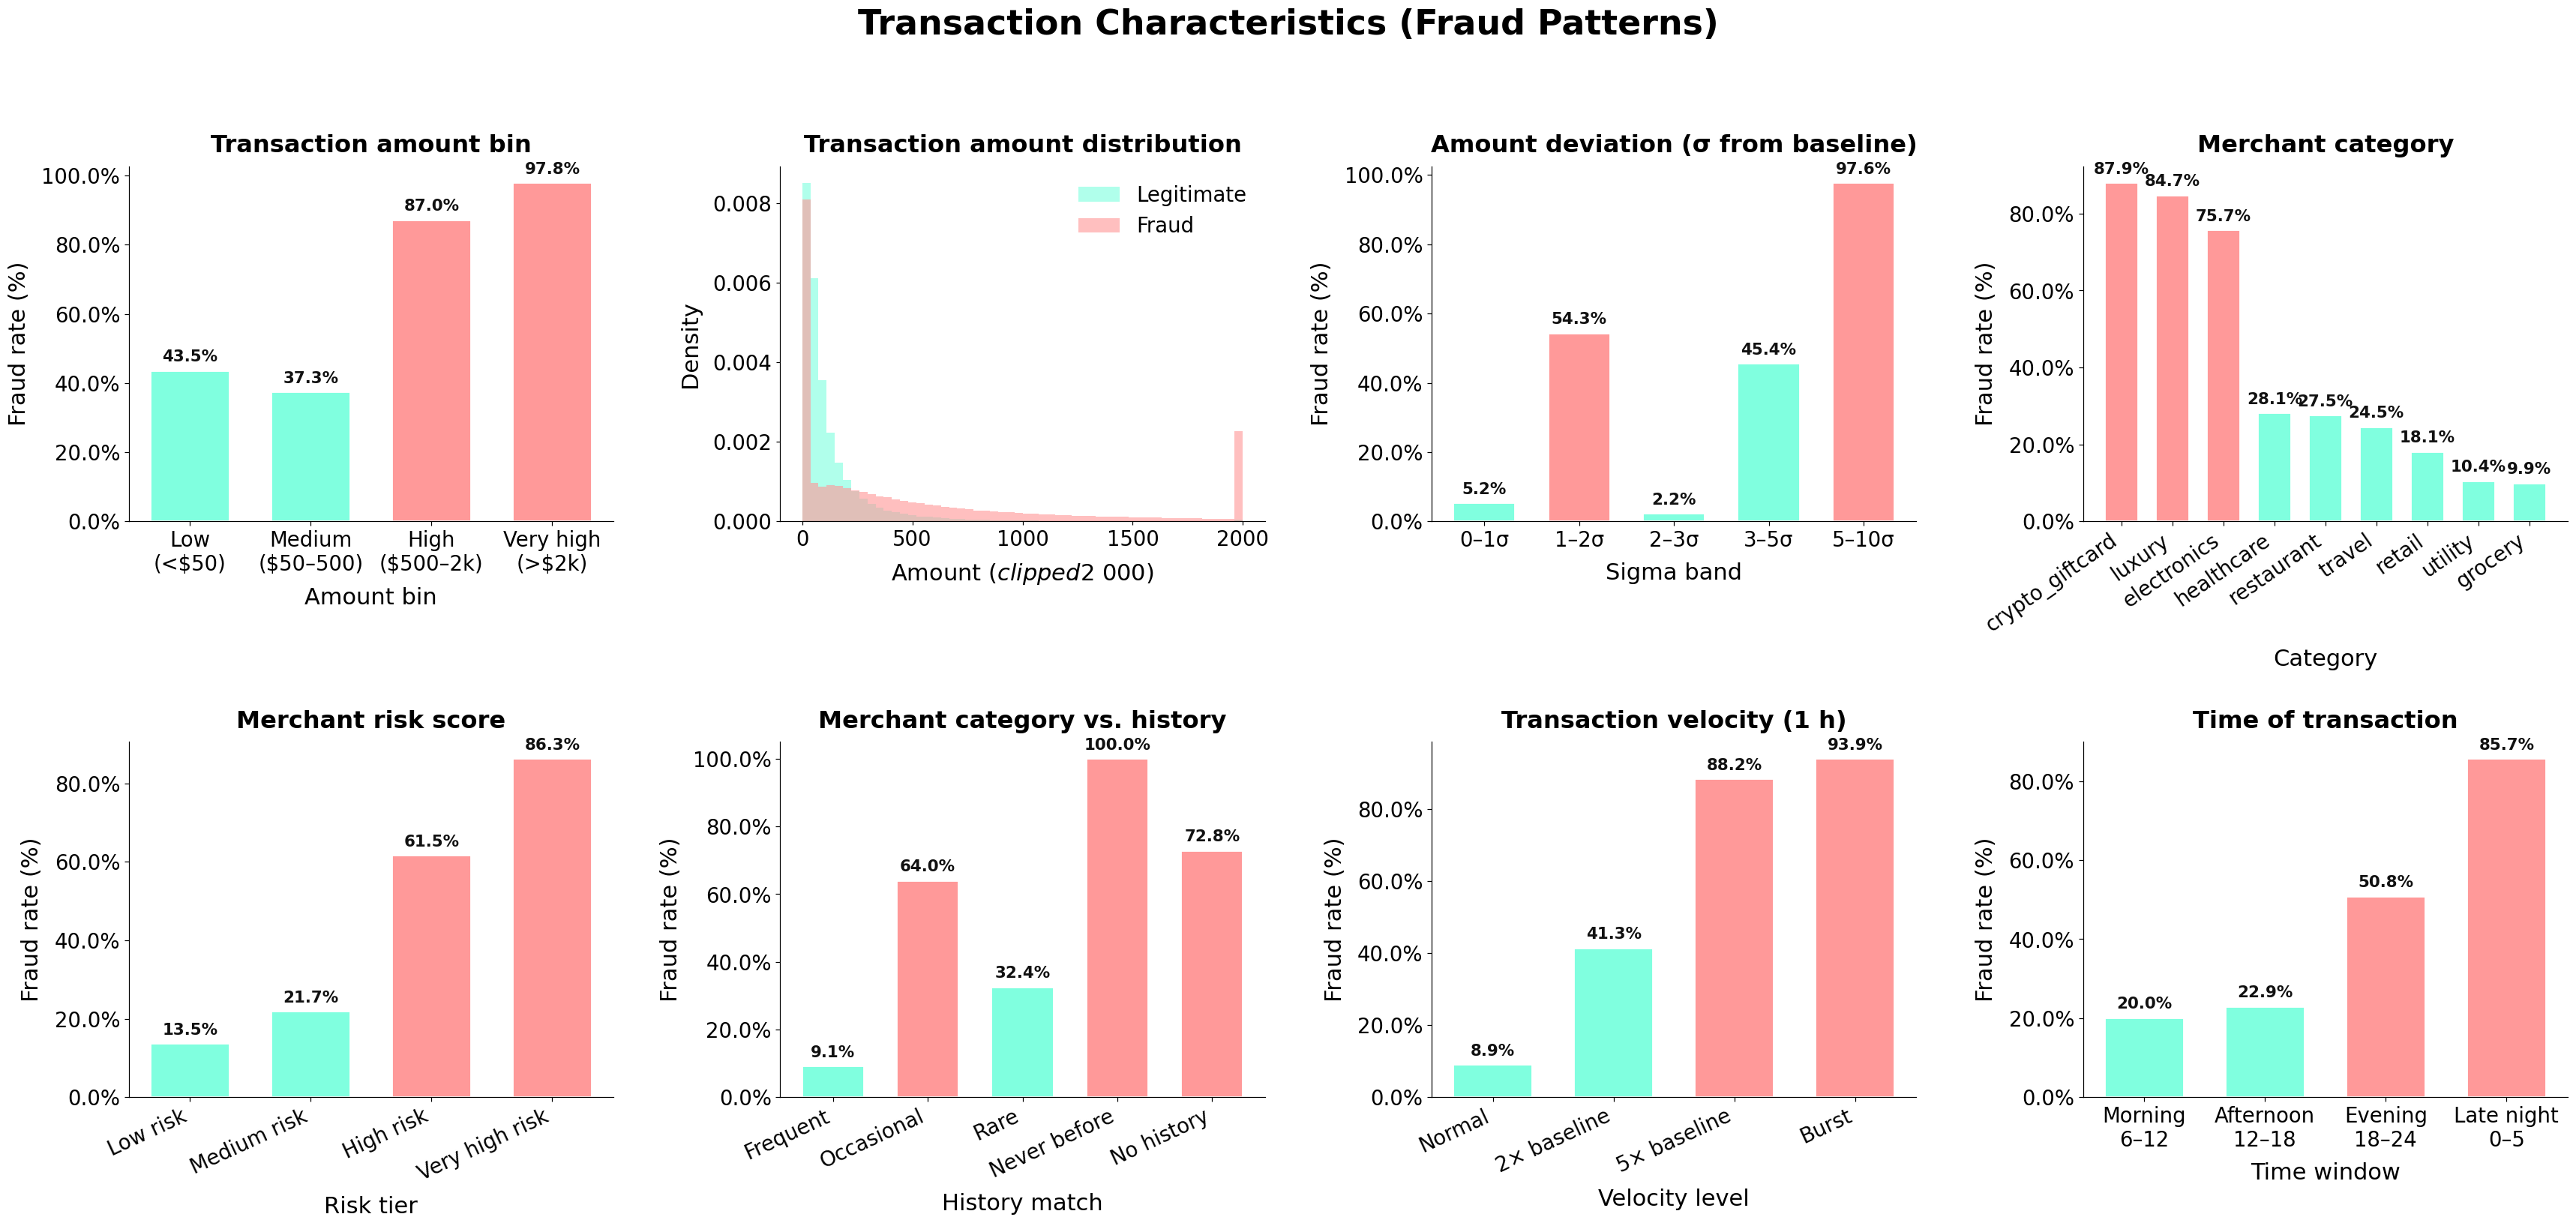

 Saved → /content/drive/MyDrive/CreditTransAct/EDA/transaction_characteristics.png


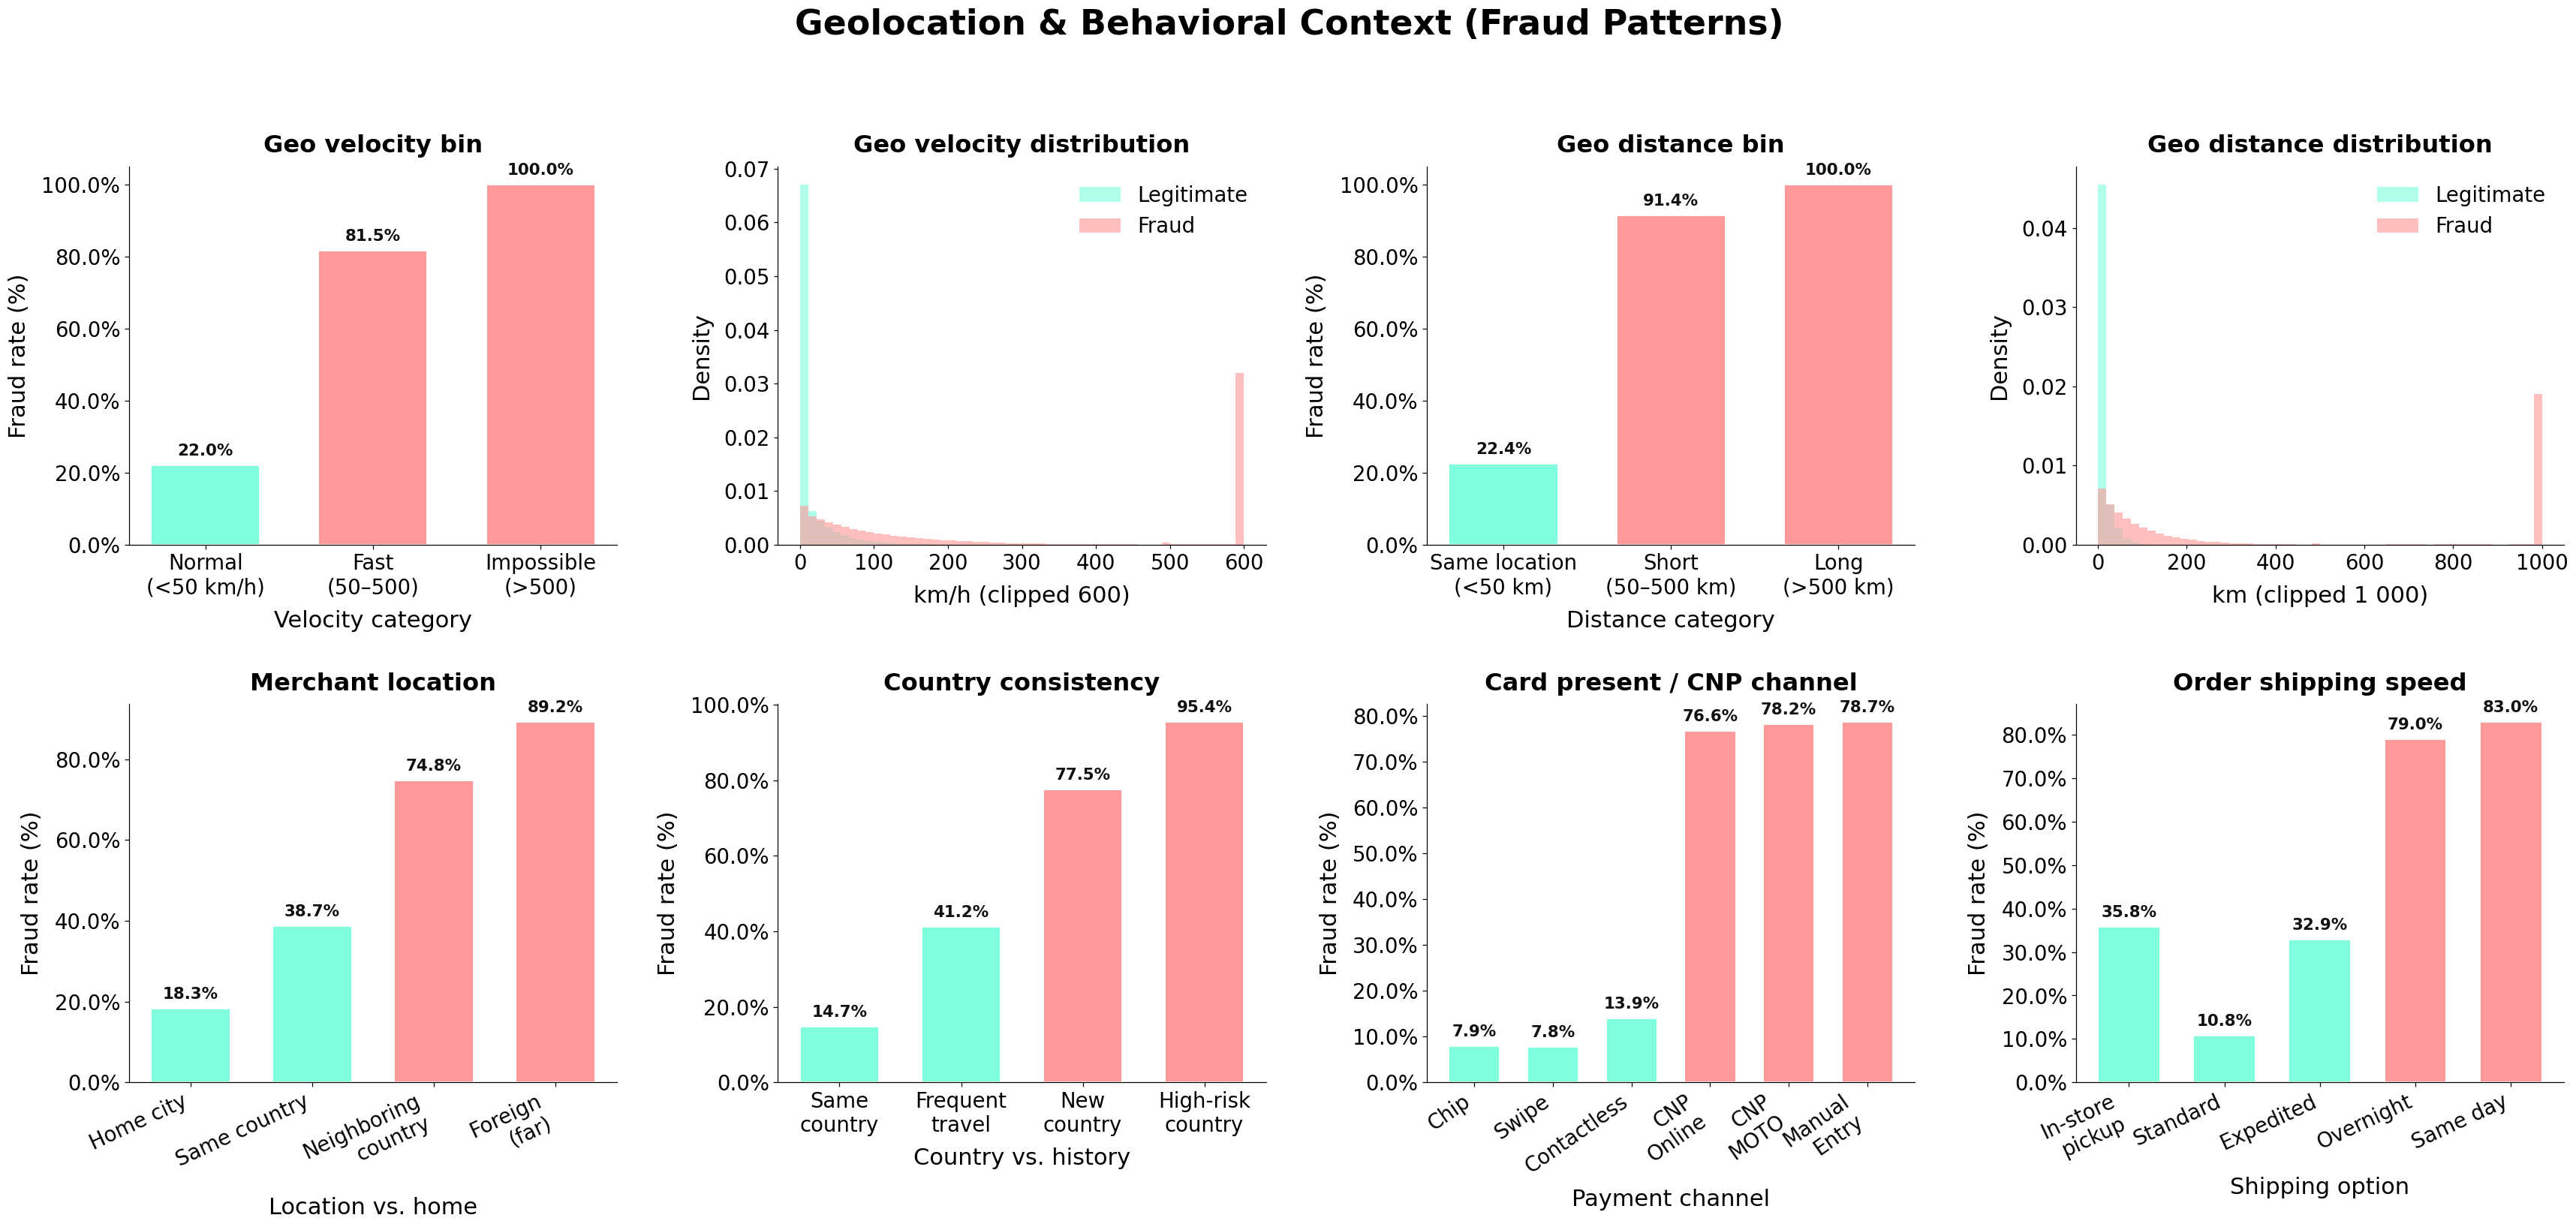

 Saved → /content/drive/MyDrive/CreditTransAct/EDA/geolocation_behavioral.png


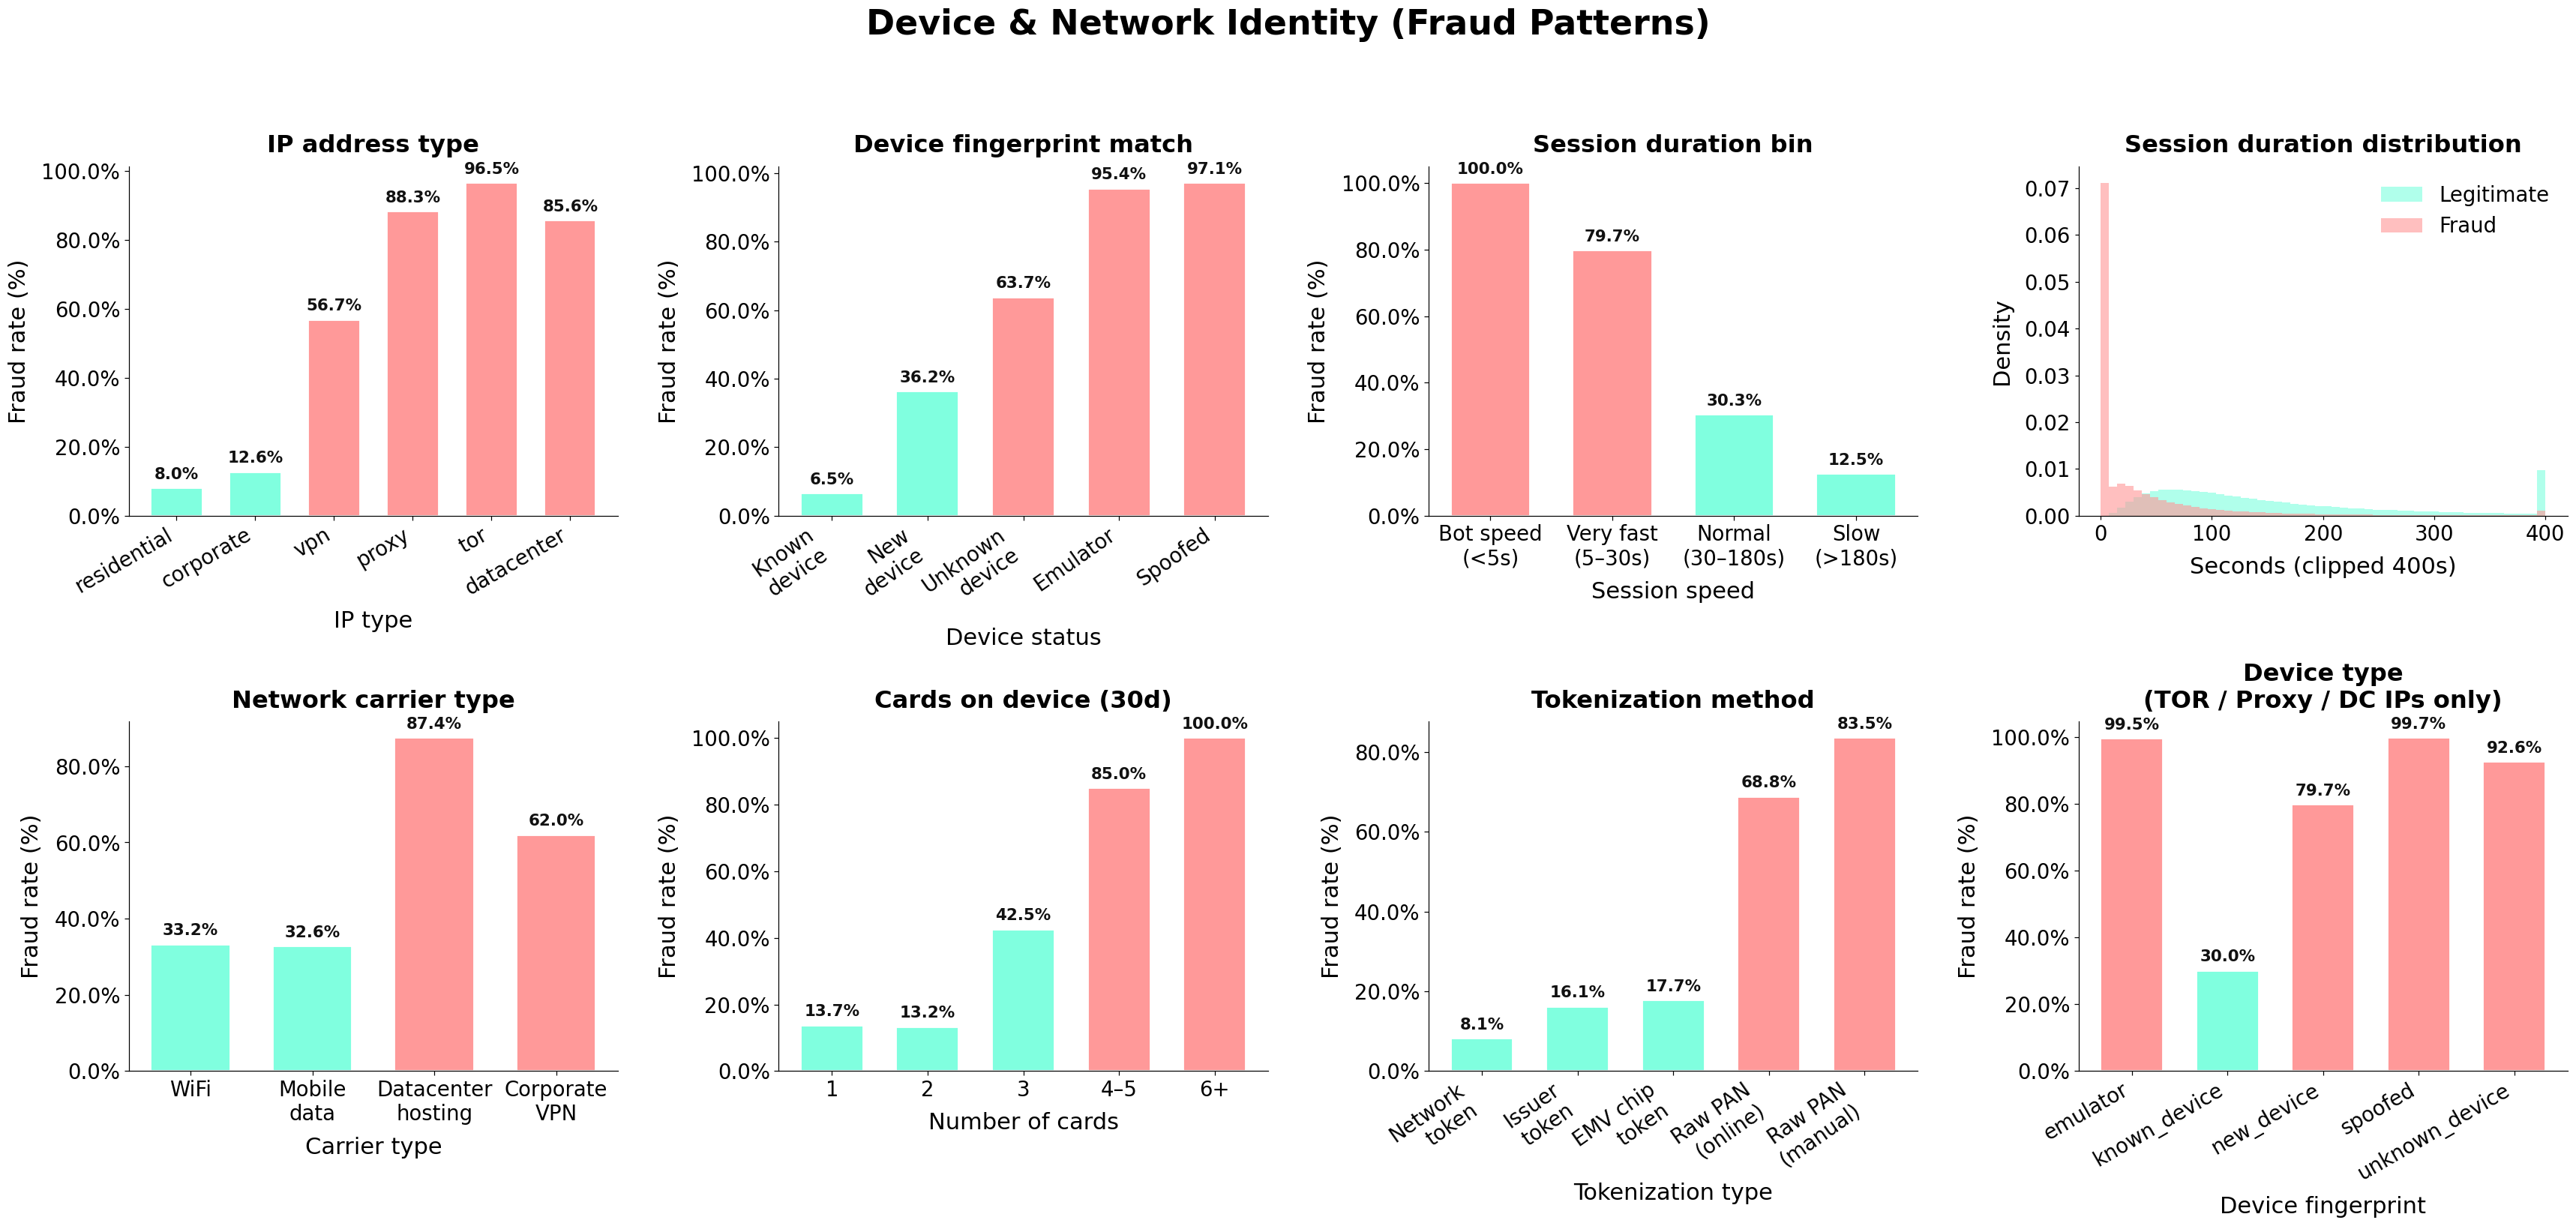

 Saved → /content/drive/MyDrive/CreditTransAct/EDA/device_network_identity.png


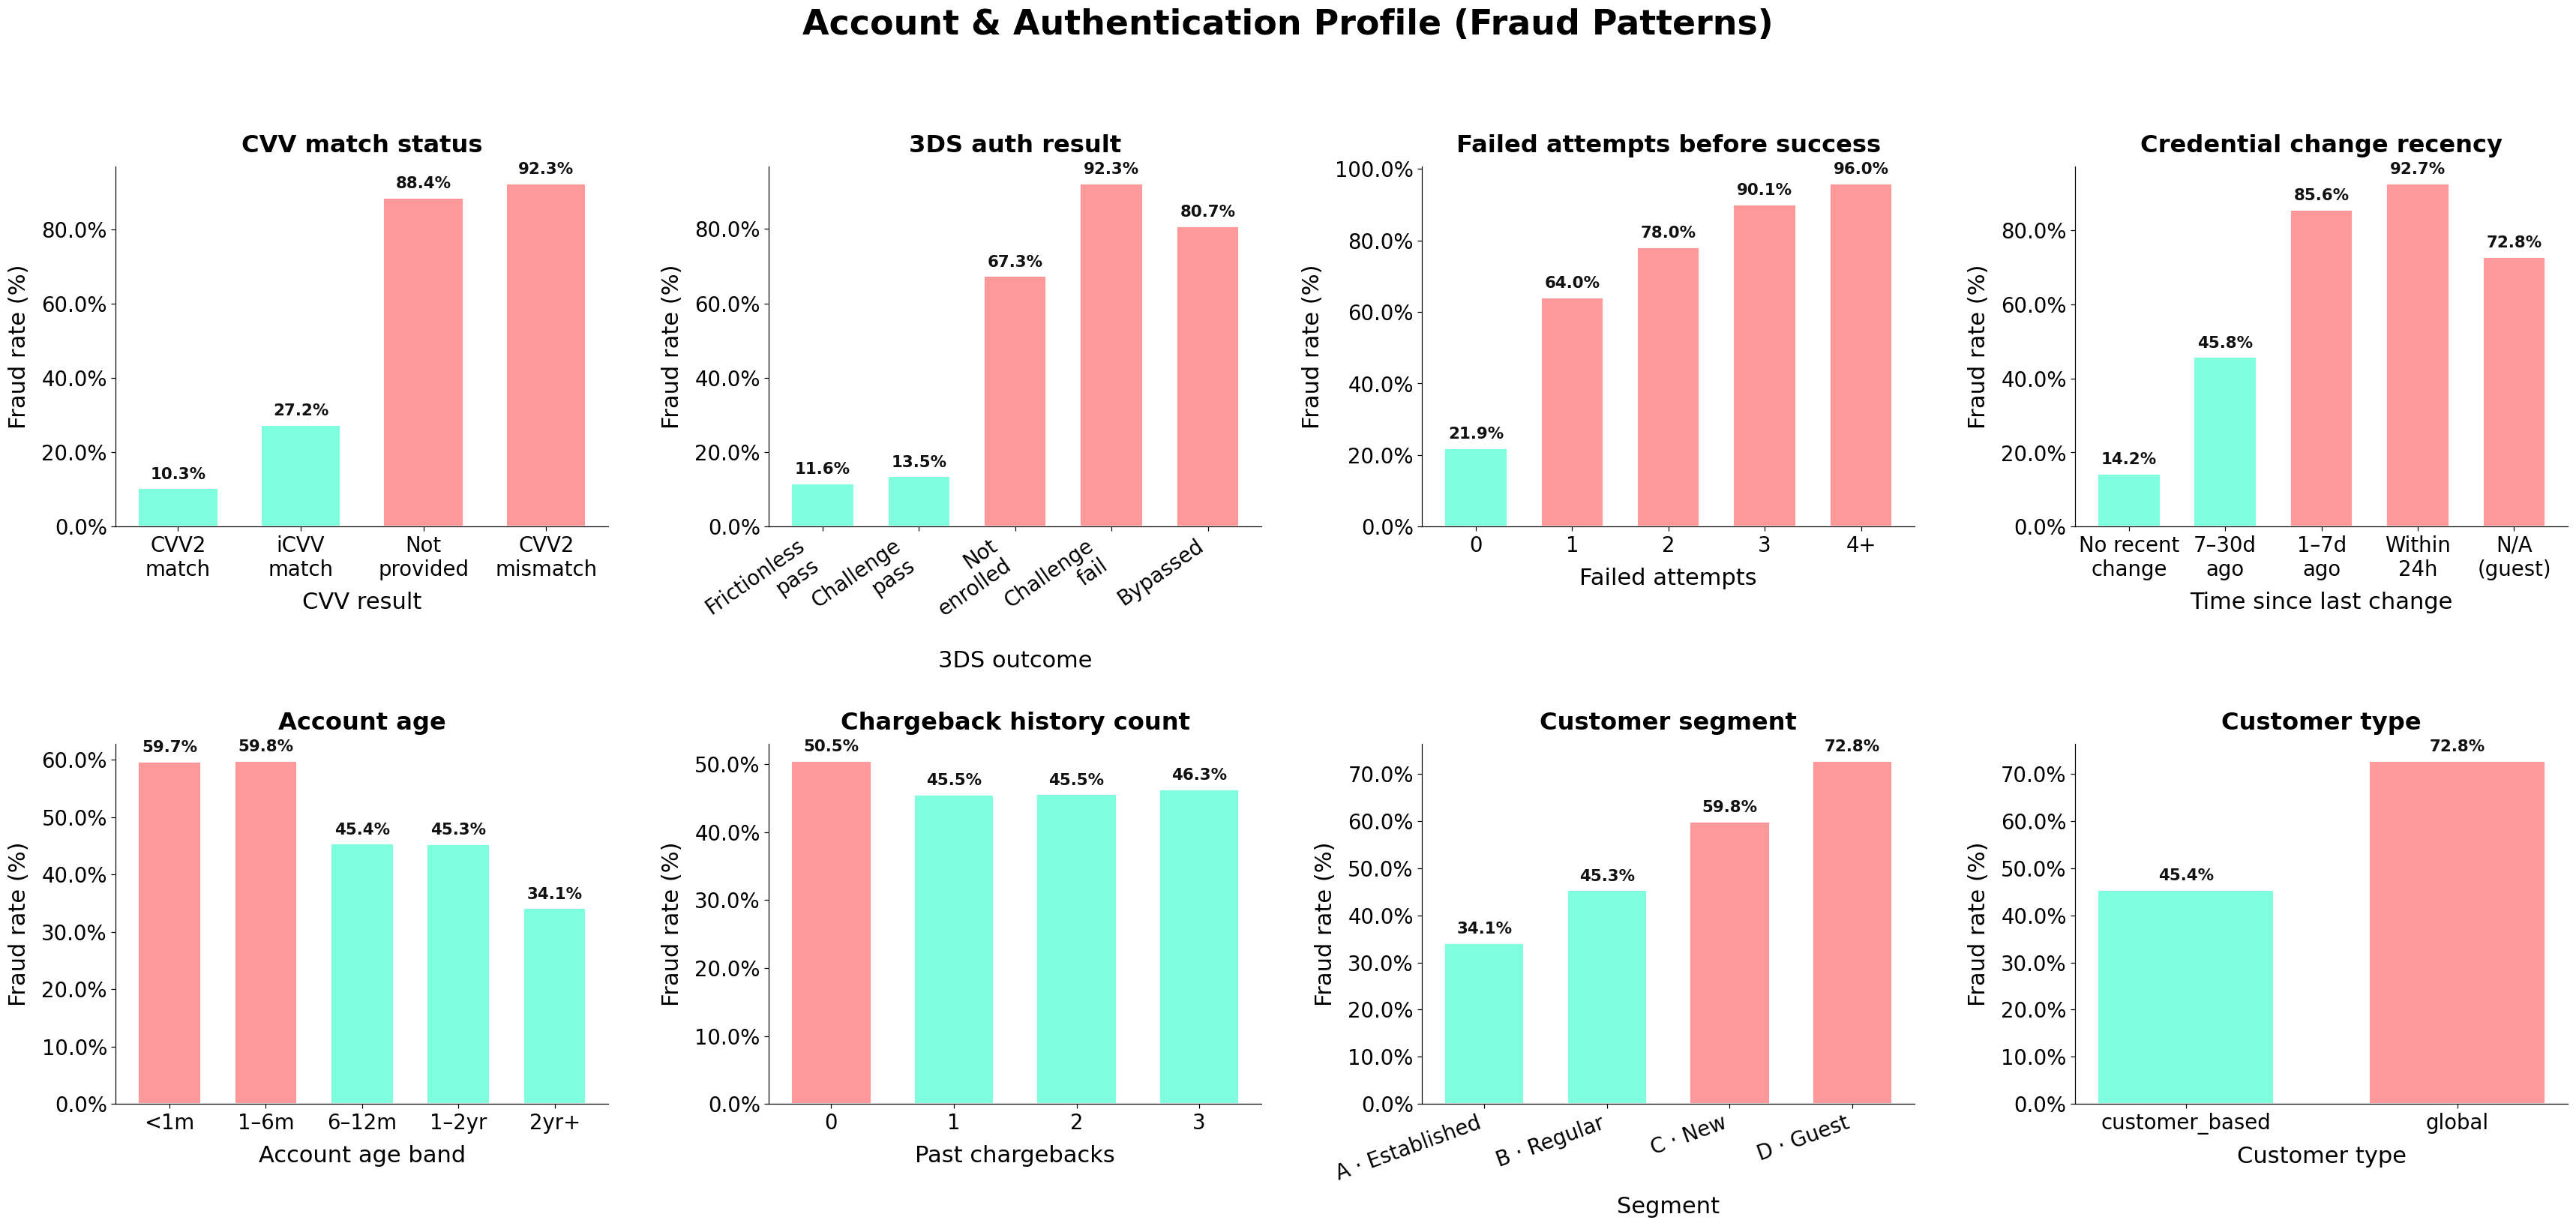

 Saved → /content/drive/MyDrive/CreditTransAct/EDA/account_authentication_profile.png


In [1]:
import subprocess, sys
for pkg in ["pyarrow", "pandas", "numpy", "matplotlib", "seaborn"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, gc, warnings
warnings.filterwarnings("ignore")

PARQUET_PATH = "/content/drive/MyDrive/CreditTransAct/credit_card_fraud.parquet"
OUTPUT_PLOTS = "/content/drive/MyDrive/CreditTransAct/EDA/"
os.makedirs(OUTPUT_PLOTS, exist_ok=True)


import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import pyarrow as pa
import pyarrow.compute as pc

SAMPLE_PER_CLASS = 500_000

pf     = pq.ParquetFile(PARQUET_PATH)
n_rows = pf.metadata.num_rows
n_cols = pf.metadata.num_columns
print(f"File: {n_rows:,} rows × {n_cols} cols")

dataset   = ds.dataset(PARQUET_PATH, format="parquet")
fraud_col = dataset.to_table(columns=["is_fraud"])
vc        = fraud_col.column("is_fraud").to_pylist()
n_fraud   = int(sum(vc)); n_legit = n_rows - n_fraud
fraud_pct = n_fraud / n_rows * 100
del fraud_col, vc; gc.collect()
print(f"Non-fraud: {n_legit:,} ({100-fraud_pct:.2f}%)  |  Fraud: {n_fraud:,} ({fraud_pct:.2f}%)")

rng = np.random.default_rng(42)

def sample_class(label, n_want):
    tbl    = dataset.to_table(filter=pc.equal(pc.field("is_fraud"), label))
    total  = len(tbl)
    idx    = np.sort(rng.choice(total, size=min(n_want, total), replace=False))
    result = tbl.take(idx).to_pandas()
    del tbl; gc.collect()
    return result

print(f"\nSampling {SAMPLE_PER_CLASS:,} rows per class...")
df_fraud = sample_class(1, SAMPLE_PER_CLASS); print(f"  Fraud : {len(df_fraud):,}")
df_legit = sample_class(0, SAMPLE_PER_CLASS); print(f"  Legit : {len(df_legit):,}")

df = pd.concat([df_fraud, df_legit], ignore_index=True)
del df_fraud, df_legit; gc.collect()
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nFinal sample: {df.shape}  |  fraud rate: {df['is_fraud'].mean()*100:.2f}%")


import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

get_ipython().run_line_magic('matplotlib', 'inline')

FRAUD_COLOR  = "#ff9999"
LEGIT_COLOR  = "#80ffdf"
OVERALL_MEAN = df["is_fraud"].mean()

FONT_SUPTITLE = 30
FONT_TITLE    = 21
FONT_LABEL    = 20
FONT_TICK     = 18
FONT_ANNOT    = 14

plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.grid":          False,
    "figure.dpi":         110,
})

def bar_color(values):
    return [FRAUD_COLOR if v > OVERALL_MEAN else LEGIT_COLOR for v in values]

def annotate_bars(ax, bars, values):
    ylim_top = ax.get_ylim()[1]
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ylim_top * 0.018,
            f"{val*100:.1f}%",
            ha="center", va="bottom",
            fontsize=FONT_ANNOT, fontweight="bold", color="#111111"
        )

def style_ax(ax, xlabel="", ylabel="Fraud rate (%)", rotate_x=False, deg=30):
    ax.set_xlabel(xlabel,  fontsize=FONT_LABEL, labelpad=10)
    ax.set_ylabel(ylabel,  fontsize=FONT_LABEL, labelpad=10)
    ax.tick_params(axis="both", labelsize=FONT_TICK, length=4)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_axisbelow(False)
    if rotate_x:
        ax.set_xticklabels(ax.get_xticklabels(),
                           rotation=deg, ha="right", fontsize=FONT_TICK)

def fraud_rate_bar(ax, col, order, labels=None, xlabel="",
                   rotate=False, deg=30, legend=False):
    fr          = df.groupby(col)["is_fraud"].mean().reindex(order)
    tick_labels = labels if labels else list(order)
    colors      = bar_color(fr.values)
    bars        = ax.bar(tick_labels, fr.values, color=colors,
                         edgecolor="white", linewidth=1.2, width=0.65)
    annotate_bars(ax, bars, fr.values)
    style_ax(ax, xlabel=xlabel, rotate_x=rotate, deg=deg)
    if legend:
        ax.legend(fontsize=FONT_TICK, frameon=False)
    return fr

def hist_overlay(ax, col, clip_hi, xlabel, bins=55):
    legit = df.loc[df["is_fraud"] == 0, col].clip(0, clip_hi)
    fraud = df.loc[df["is_fraud"] == 1, col].clip(0, clip_hi)
    b     = np.linspace(0, clip_hi, bins)
    ax.hist(legit, bins=b, color=LEGIT_COLOR, alpha=0.62,
            label="Legitimate", density=True, edgecolor="none")
    ax.hist(fraud, bins=b, color=FRAUD_COLOR, alpha=0.62,
            label="Fraud",      density=True, edgecolor="none")
    ax.set_xlabel(xlabel,    fontsize=FONT_LABEL, labelpad=10)
    ax.set_ylabel("Density", fontsize=FONT_LABEL, labelpad=10)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_TICK, frameon=False)

def save_fig(fig, fname):
    """Save figure to Drive AND display it inline in the notebook output."""
    path = os.path.join(OUTPUT_PLOTS, fname)
    fig.savefig(path, bbox_inches="tight", facecolor="white", dpi=140)
    plt.show()
    plt.close(fig)
    gc.collect()
    print(f" Saved → {path}")

print("Helpers ready. Overall fraud rate:", f"{OVERALL_MEAN*100:.2f}%")



# FIGURE 1 — Transaction Characteristics
fig, axes = plt.subplots(2, 4, figsize=(32, 15))
fig.suptitle("Transaction Characteristics (Fraud Patterns)",
             fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01)
axes = axes.flatten()

ax = axes[0]
fraud_rate_bar(ax, "transaction_amount_bin",
               order=["low","medium","high","very_high"],
               labels=["Low\n(<$50)","Medium\n($50–500)","High\n($500–2k)","Very high\n(>$2k)"],
               xlabel="Amount bin", legend=True)
ax.set_title("Transaction amount bin", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[1]
hist_overlay(ax, "transaction_amount", clip_hi=2000, xlabel="Amount $ (clipped $2 000)")
ax.set_title("Transaction amount distribution", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[2]
df["_sigma_bin"] = pd.cut(df["avg_amount_deviation_sigma"],
                           bins=[0,1,2,3,5,10],
                           labels=["0–1σ","1–2σ","2–3σ","3–5σ","5–10σ"])
fraud_rate_bar(ax, "_sigma_bin",
               order=["0–1σ","1–2σ","2–3σ","3–5σ","5–10σ"],
               xlabel="Sigma band")
ax.set_title("Amount deviation (σ from baseline)", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[3]
mc_order = (df.groupby("merchant_category")["is_fraud"]
              .mean().sort_values(ascending=False).index.tolist())
fraud_rate_bar(ax, "merchant_category", order=mc_order,
               xlabel="Category", rotate=True, deg=35)
ax.set_title("Merchant category", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[4]
fraud_rate_bar(ax, "merchant_risk_score",
               order=["low_risk","medium_risk","high_risk","very_high_risk"],
               labels=["Low risk","Medium risk","High risk","Very high risk"],
               xlabel="Risk tier", rotate=True, deg=25)
ax.set_title("Merchant risk score", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[5]
fraud_rate_bar(ax, "merchant_category_vs_history",
               order=["frequent_category","occasional_category",
                      "rare_category","never_before_category","no_history"],
               labels=["Frequent","Occasional","Rare","Never before","No history"],
               xlabel="History match", rotate=True, deg=25)
ax.set_title("Merchant category vs. history", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[6]
fraud_rate_bar(ax, "transaction_velocity_1h",
               order=["within_normal","2x_baseline","5x_baseline","burst_pattern"],
               labels=["Normal","2× baseline","5× baseline","Burst"],
               xlabel="Velocity level", rotate=True, deg=25)
ax.set_title("Transaction velocity (1 h)", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[7]
fraud_rate_bar(ax, "time_of_transaction",
               order=["morning_6_12","afternoon_12_18","evening_18_24","late_night_0_5"],
               labels=["Morning\n6–12","Afternoon\n12–18","Evening\n18–24","Late night\n0–5"],
               xlabel="Time window")
ax.set_title("Time of transaction", fontsize=FONT_TITLE, fontweight="bold", pad=12)

df.drop(columns=["_sigma_bin"], errors="ignore", inplace=True)
fig.tight_layout(pad=3.5)
save_fig(fig, "transaction_characteristics.png")


# FIGURE 2 — Geolocation & Behavioral Context
fig, axes = plt.subplots(2, 4, figsize=(32, 15))
fig.suptitle("Geolocation & Behavioral Context (Fraud Patterns)",
             fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01)
axes = axes.flatten()

ax = axes[0]
fraud_rate_bar(ax, "geo_velocity_bin",
               order=["normal","fast","impossible"],
               labels=["Normal\n(<50 km/h)","Fast\n(50–500)","Impossible\n(>500)"],
               xlabel="Velocity category", legend=True)
ax.set_title("Geo velocity bin", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[1]
hist_overlay(ax, "geo_velocity_kmh", clip_hi=600, xlabel="km/h (clipped 600)")
ax.set_title("Geo velocity distribution", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[2]
fraud_rate_bar(ax, "geo_distance_bin",
               order=["same_location","short","long"],
               labels=["Same location\n(<50 km)","Short\n(50–500 km)","Long\n(>500 km)"],
               xlabel="Distance category")
ax.set_title("Geo distance bin", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[3]
hist_overlay(ax, "geo_distance_km", clip_hi=1000, xlabel="km (clipped 1 000)")
ax.set_title("Geo distance distribution", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[4]
fraud_rate_bar(ax, "merchant_location",
               order=["home_city","same_country","neighboring_country","foreign_far"],
               labels=["Home city","Same country","Neighboring\ncountry","Foreign\n(far)"],
               xlabel="Location vs. home", rotate=True, deg=25)
ax.set_title("Merchant location", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[5]
fraud_rate_bar(ax, "country_consistency",
               order=["same_country","frequent_travel_country","new_country","high_risk_country"],
               labels=["Same\ncountry","Frequent\ntravel","New\ncountry","High-risk\ncountry"],
               xlabel="Country vs. history")
ax.set_title("Country consistency", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[6]
fraud_rate_bar(ax, "card_present_cnp",
               order=["card_present_chip","card_present_swipe","contactless",
                      "cnp_online","cnp_moto","manual_entry"],
               labels=["Chip","Swipe","Contactless","CNP\nOnline","CNP\nMOTO","Manual\nEntry"],
               xlabel="Payment channel", rotate=True, deg=35)
ax.set_title("Card present / CNP channel", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[7]
fraud_rate_bar(ax, "order_shipping_speed",
               order=["in_store_pickup","standard","expedited","overnight","same_day"],
               labels=["In-store\npickup","Standard","Expedited","Overnight","Same day"],
               xlabel="Shipping option", rotate=True, deg=25)
ax.set_title("Order shipping speed", fontsize=FONT_TITLE, fontweight="bold", pad=12)

fig.tight_layout(pad=3.5)
save_fig(fig, "geolocation_behavioral.png")


# FIGURE 3 — Device & Network Identity
fig, axes = plt.subplots(2, 4, figsize=(32, 15))
fig.suptitle("Device & Network Identity (Fraud Patterns)",
             fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01)
axes = axes.flatten()

ax = axes[0]
fraud_rate_bar(ax, "ip_address_type",
               order=["residential","corporate","vpn","proxy","tor","datacenter"],
               xlabel="IP type", rotate=True, deg=30, legend=True)
ax.set_title("IP address type", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[1]
fraud_rate_bar(ax, "device_fingerprint_match",
               order=["known_device","new_device","unknown_device","emulator","spoofed"],
               labels=["Known\ndevice","New\ndevice","Unknown\ndevice","Emulator","Spoofed"],
               xlabel="Device status", rotate=True, deg=35)
ax.set_title("Device fingerprint match", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[2]
fraud_rate_bar(ax, "session_duration_bin",
               order=["bot_speed","very_fast","normal","slow"],
               labels=["Bot speed\n(<5s)","Very fast\n(5–30s)","Normal\n(30–180s)","Slow\n(>180s)"],
               xlabel="Session speed")
ax.set_title("Session duration bin", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[3]
hist_overlay(ax, "session_duration_sec", clip_hi=400, xlabel="Seconds (clipped 400s)")
ax.set_title("Session duration distribution", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[4]
fraud_rate_bar(ax, "network_carrier_type",
               order=["wifi","mobile_data","datacenter_hosting","corporate_vpn"],
               labels=["WiFi","Mobile\ndata","Datacenter\nhosting","Corporate\nVPN"],
               xlabel="Carrier type")
ax.set_title("Network carrier type", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[5]
df["_cards_bin"] = pd.cut(df["cards_on_device_30d"],
                           bins=[0,1,2,3,5,25], right=True,
                           labels=["1","2","3","4–5","6+"])
fraud_rate_bar(ax, "_cards_bin",
               order=["1","2","3","4–5","6+"],
               xlabel="Number of cards")
ax.set_title("Cards on device (30d)", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[6]
fraud_rate_bar(ax, "tokenization_used",
               order=["network_token_wallet","issuer_token","emv_chip_token",
                      "raw_pan_online","raw_pan_manual_entry"],
               labels=["Network\ntoken","Issuer\ntoken","EMV chip\ntoken",
                       "Raw PAN\n(online)","Raw PAN\n(manual)"],
               xlabel="Tokenization type", rotate=True, deg=35)
ax.set_title("Tokenization method", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[7]
bot_df   = df[df["ip_address_type"].isin(["tor","proxy","datacenter"])].copy()
fr_bot   = bot_df.groupby("device_fingerprint_match")["is_fraud"].mean()
colors_b = bar_color(fr_bot.values)
bars     = ax.bar(fr_bot.index, fr_bot.values, color=colors_b,
                  edgecolor="white", linewidth=1.2, width=0.65)
annotate_bars(ax, bars, fr_bot.values)
style_ax(ax, xlabel="Device fingerprint", rotate_x=True, deg=30)
ax.set_title("Device type\n(TOR / Proxy / DC IPs only)",
             fontsize=FONT_TITLE, fontweight="bold", pad=12)
del bot_df

df.drop(columns=["_cards_bin"], errors="ignore", inplace=True)
fig.tight_layout(pad=3.5)
save_fig(fig, "device_network_identity.png")


# FIGURE 4 — Account & Authentication Profile
fig, axes = plt.subplots(2, 4, figsize=(32, 15))
fig.suptitle("Account & Authentication Profile (Fraud Patterns)",
             fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01)
axes = axes.flatten()

ax = axes[0]
fraud_rate_bar(ax, "cvv_match_status",
               order=["cvv2_match","icvv_match","not_provided","cvv2_mismatch"],
               labels=["CVV2\nmatch","iCVV\nmatch","Not\nprovided","CVV2\nmismatch"],
               xlabel="CVV result", legend=True)
ax.set_title("CVV match status", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[1]
fraud_rate_bar(ax, "three_ds_auth_result",
               order=["frictionless_pass","challenge_pass","not_enrolled",
                      "challenge_fail","bypassed"],
               labels=["Frictionless\npass","Challenge\npass","Not\nenrolled",
                       "Challenge\nfail","Bypassed"],
               xlabel="3DS outcome", rotate=True, deg=35)
ax.set_title("3DS auth result", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[2]
df["_fail_bin"] = pd.cut(df["failed_attempts_before_success"],
                          bins=[-0.5,0.5,1.5,2.5,3.5,15],
                          labels=["0","1","2","3","4+"])
fraud_rate_bar(ax, "_fail_bin",
               order=["0","1","2","3","4+"],
               xlabel="Failed attempts")
ax.set_title("Failed attempts before success", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[3]
fraud_rate_bar(ax, "account_credential_change_recency",
               order=["no_recent_change","changed_7_30d_ago",
                      "changed_1_7d_ago","changed_within_24h","not_applicable"],
               labels=["No recent\nchange","7–30d\nago","1–7d\nago",
                       "Within\n24h","N/A\n(guest)"],
               xlabel="Time since last change")
ax.set_title("Credential change recency", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[4]
df["_age_bin"] = pd.cut(df["account_age_days"],
                         bins=[0,30,180,365,730,3650],
                         labels=["<1m","1–6m","6–12m","1–2yr","2yr+"])
fraud_rate_bar(ax, "_age_bin",
               order=["<1m","1–6m","6–12m","1–2yr","2yr+"],
               xlabel="Account age band")
ax.set_title("Account age", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[5]
fraud_rate_bar(ax, "chargeback_history_count",
               order=sorted(df["chargeback_history_count"].unique()),
               xlabel="Past chargebacks")
ax.set_title("Chargeback history count", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[6]
fraud_rate_bar(ax, "segment",
               order=["A_established","B_regular","C_new","D_guest"],
               labels=["A · Established","B · Regular","C · New","D · Guest"],
               xlabel="Segment", rotate=True, deg=20)
ax.set_title("Customer segment", fontsize=FONT_TITLE, fontweight="bold", pad=12)

ax = axes[7]
fraud_rate_bar(ax, "customer_type",
               order=df["customer_type"].value_counts().index.tolist(),
               xlabel="Customer type")
ax.set_title("Customer type", fontsize=FONT_TITLE, fontweight="bold", pad=12)

df.drop(columns=["_fail_bin","_age_bin"], errors="ignore", inplace=True)
fig.tight_layout(pad=3.5)
save_fig(fig, "account_authentication_profile.png")

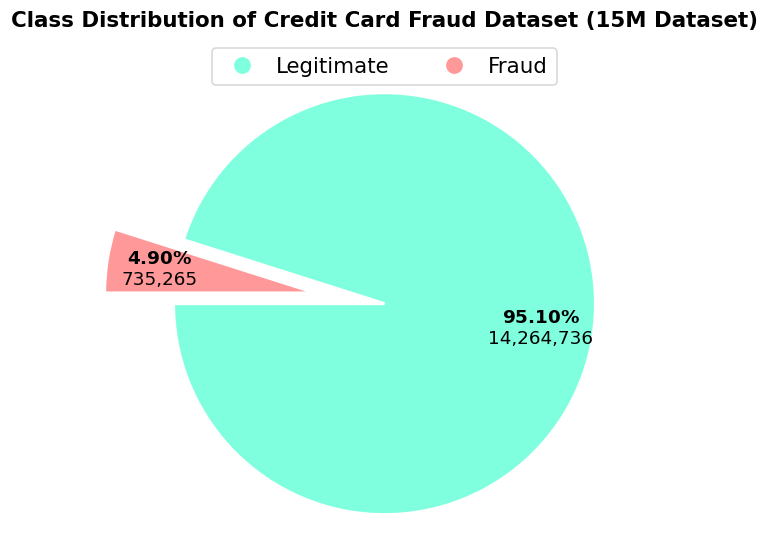

In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os, gc

FRAUD_COLOR  = "#ff9999"
LEGIT_COLOR  = "#80ffdf"

OUTPUT_PLOTS = "/content/drive/MyDrive/CreditTransAct/EDA/"
os.makedirs(OUTPUT_PLOTS, exist_ok=True)


def save_fig(fig, fname):
    path = os.path.join(OUTPUT_PLOTS, fname)
    fig.savefig(path, bbox_inches="tight", dpi=140)
    plt.show()
    plt.close(fig)
    gc.collect()


fig, ax = plt.subplots(figsize=(6, 5))

fig.suptitle(
    "Class Distribution of Credit Card Fraud Dataset (15M Dataset)",
    fontsize=14,
    fontweight="bold"
)

PAL = [LEGIT_COLOR, FRAUD_COLOR]

counts = [n_legit, n_fraud]
labels = ["Legitimate", "Fraud"]

explode = [0, 0.38]

def autopct_format(pct):
    total = sum(counts)
    val = int(round(pct * total / 100))
    return f"$\\bf{{{pct:.2f}\\%}}$\n{val:,}"

wedges, texts, autotexts = ax.pie(
    counts,
    colors=PAL,
    startangle=180,
    explode=explode,
    autopct=autopct_format,
    pctdistance=0.75,
    radius=1.15,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops={"fontsize": 12}
)


for t in texts:
    t.set_text("")


for at in autotexts:
    at.set_color("black")

legend_handles = [
    Line2D([0], [0], marker='o', color='w', label=labels[i],
           markerfacecolor=PAL[i],
           markersize=12)
    for i in range(len(labels))
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=2,
    frameon=True,
    fontsize=14,
    handlelength=2,
    handletextpad=0.6
)

plt.subplots_adjust(top=0.82, bottom=0.08)
plt.tight_layout()

save_fig(fig, "class_distribution.png")

In [ ]:
SAMPLE_PATH = "/content/drive/MyDrive/CreditTransAct/eda_sample_1M.parquet"
df.to_parquet(SAMPLE_PATH, index=False, compression="snappy")
print(f"   Shape: {df.shape}")

   Shape: (1000000, 34)


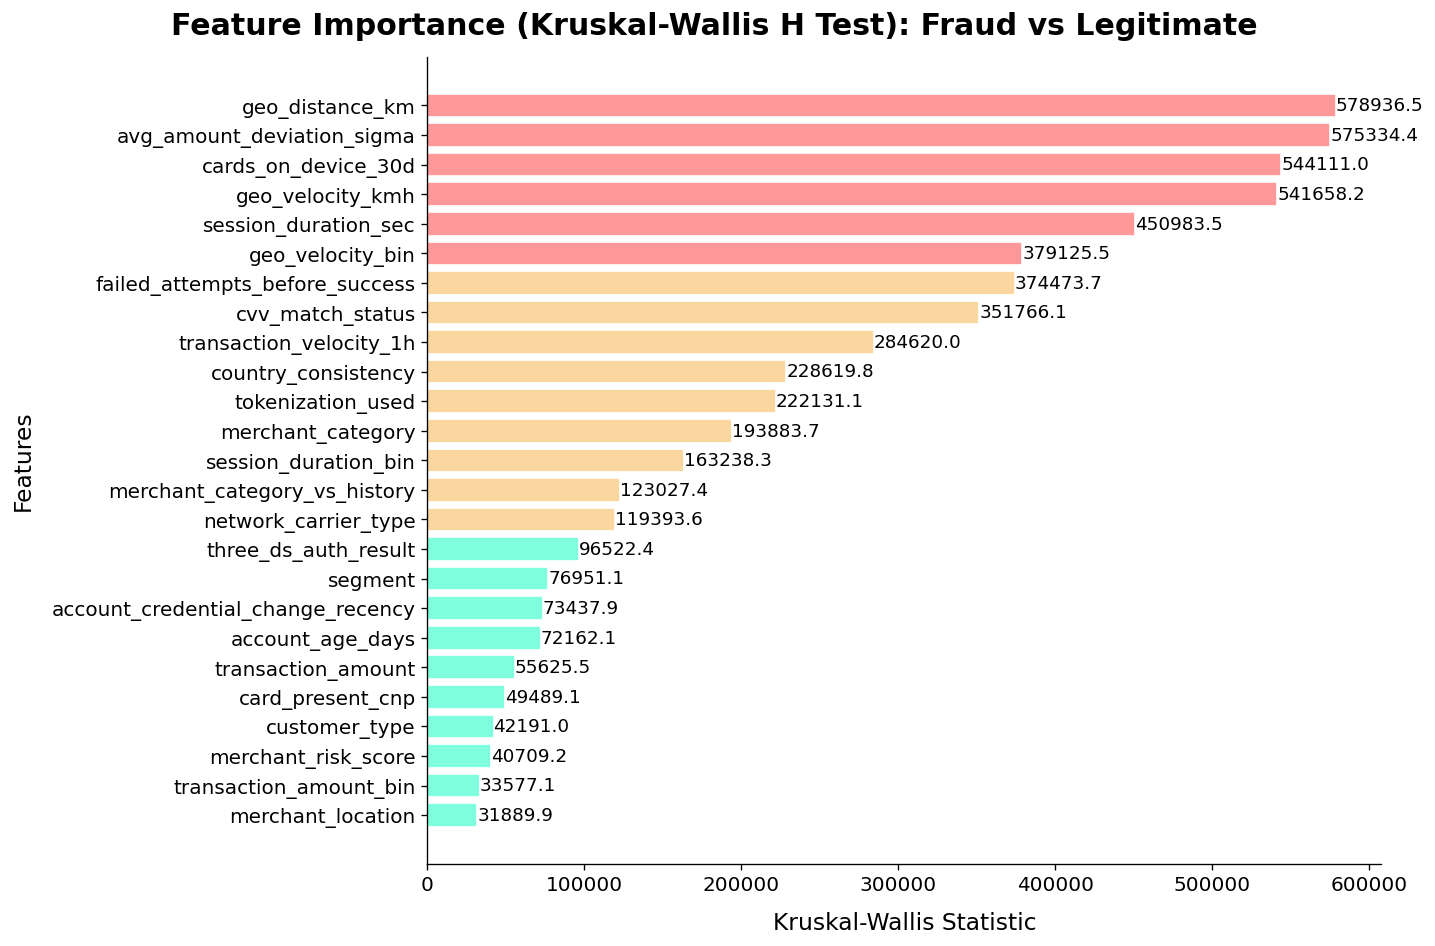

Saved → feature_importance_kruskal.png


0

In [3]:
import subprocess, sys, os, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from sklearn.preprocessing import LabelEncoder

for pkg in ["pyarrow","pandas","numpy","matplotlib","scipy","scikit-learn"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

SAMPLE_PATH  = "/content/drive/MyDrive/CreditTransAct/eda_sample_1M.parquet"
OUTPUT_DIR   = "/content/drive/MyDrive/CreditTransAct/EDA/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

C_FRAUD = "#ff9999"
C_LEGIT = "#80ffdf"
C_WARN  = "#fad79e"


plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.family": "DejaVu Sans"
})

FONT_TITLE = 16
FONT_LABEL = 14
FONT_TICK  = 12


def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, bbox_inches="tight", facecolor="white", dpi=140)

    plt.show()

    plt.close(fig)
    gc.collect()

    print(f"Saved → {name}")


df = pd.read_parquet(SAMPLE_PATH)

df_enc = df.copy()

for col in df_enc.select_dtypes(include="object").columns:
    if col not in ["customer_id", "transaction_id"]:
        df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

feature_cols = [
    c for c in df_enc.columns
    if c not in ["customer_id", "transaction_id", "is_fraud"]
]


scores = []

for feat in feature_cols:
    try:
        g0 = df_enc[df_enc["is_fraud"] == 0][feat].dropna()
        g1 = df_enc[df_enc["is_fraud"] == 1][feat].dropna()

        if len(g0) > 10 and len(g1) > 10:
            stat, _ = kruskal(g0, g1)
            scores.append((feat, stat))
    except:
        continue

kruskal_df = pd.DataFrame(scores, columns=["feature", "score"])
kruskal_df = kruskal_df.sort_values("score", ascending=True).tail(25)
kruskal_df = kruskal_df.sort_values("score", ascending=True)

q1 = kruskal_df["score"].quantile(0.40)
q3 = kruskal_df["score"].quantile(0.75)

colors = [
    C_FRAUD if v > q3 else
    C_WARN  if v > q1 else
    C_LEGIT
    for v in kruskal_df["score"]
]


fig, ax = plt.subplots(figsize=(12, 8))

fig.suptitle(
    "Feature Importance (Kruskal-Wallis H Test): Fraud vs Legitimate",
    fontsize=FONT_TITLE + 2,
    fontweight="bold"
)

ax.barh(
    kruskal_df["feature"],
    kruskal_df["score"],
    color=colors,
    edgecolor="white",
    linewidth=1
)

ax.set_xlabel("Kruskal-Wallis Statistic", fontsize=FONT_LABEL, labelpad=10)
ax.set_ylabel("Features", fontsize=FONT_LABEL, labelpad=10)

ax.tick_params(axis="both", labelsize=FONT_TICK)

for i, v in enumerate(kruskal_df["score"]):
    ax.text(v, i, f"{v:.1f}", va="center", fontsize=11)

plt.tight_layout()

save(fig, "feature_importance_kruskal.png")

gc.collect()